<a href="https://colab.research.google.com/github/AanyaAgrahari28/satellite-land-use-change-detection/blob/main/Land_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI-Based Satellite Land-Use Classification and Environmental Change Detection

---

## Project Overview

This project uses deep learning to analyze satellite images and classify land-use types such as forests, residential areas, rivers, and crops.

The system also compares two satellite images taken at different times to detect environmental changes such as urban expansion or agricultural development.

A convolutional neural network (CNN) is trained on the EuroSAT dataset, and an AI-based transition analysis system is used to interpret land-use changes between two images.

---

## Key Features

- CNN-based satellite land-use classification.
- Comparison of two CNN models and architecture optimization.
- Detection of environmental land-use transitions between two images.
- Interpretation of transitions (e.g., urban expansion, agricultural growth).
- Confidence-based risk score estimation.
---


## Dataset

The project uses the **EuroSAT satellite image dataset**, which contains labeled satellite images for land-use classification.

Classes included in the dataset:

- AnnualCrop  
- Forest  
- HerbaceousVegetation  
- Highway  
- Industrial  
- Pasture  
- PermanentCrop  
- Residential  
- River  
- SeaLake  

Each image is a **64 × 64 satellite patch**.  
The dataset is divided into **training, validation, and testing sets** for model evaluation.

---

## Model Development

Two CNN models were developed for satellite image classification.

**Model A – Baseline CNN**
- Initial convolutional neural network architecture.
- Showed overfitting due to high parameter count.

**Model B – Optimized CNN**
- Reduced parameters
- Added dropout for regularization
- Applied data augmentation

Model B achieved better generalization and was used in the final system.

---

## Model Performance

| Model | Description | Parameters | Accuracy |
|------|-------------|------------|----------|
| Model A | Baseline CNN | ~6.9M | ~65% |
| Model B | Optimized CNN + Dropout | ~1.6M | ~78% |

Model B reduced model complexity and improved performance, so it was selected for the final system.

---

## Environmental Change Detection System

The project extends beyond simple image classification by introducing a land-use change detection system.

The trained CNN model is used to analyze two satellite images taken at different times and detect land-use transitions.

The system:

1. Classifies both satellite images.
2. Maps the predicted classes to broader land categories:
   - Natural
   - Agricultural
   - Built-Up
3. Detects transitions between categories.
4. Interprets environmental impact (e.g., urban expansion).
5. Calculates a confidence-based **risk score**.


---

## Transition Interpretation and Risk Assessment
Once a change is detected, the system provides a qualitative interpretation of the environmental transition.

Examples include:

1) Forest → Residential
 : Possible Urban Expansion

2) Forest → Agricultural Land
 : Possible Agricultural Expansion

3) Residential → Industrial :
Possible Industrial Development

To provide additional context, the system also calculates a risk score based on model confidence and classifies the change impact as:

1) High Impact

2) Moderate Impact

3) Low Impact

This interpretation layer makes the system more useful for environmental monitoring applications.

___


# How to Run the Project

1. Open the Jupyter/Colab notebook.

2. Run all cells to train or load the model.

3. Provide two satellite images representing before and after conditions.

4. Run the change detection function to analyze land-use transitions.
___

In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
!nvidia-smi


Fri Mar 13 21:00:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             27W /   70W |     637MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!wget http://madm.dfki.de/files/sentinel/EuroSAT.zip
!unzip EuroSAT.zip


--2026-03-13 21:00:18--  http://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:80... connected.
HTTP request sent, awaiting response... 403 Forbidden
2026-03-13 21:00:19 ERROR 403: Forbidden.

unzip:  cannot find or open EuroSAT.zip, EuroSAT.zip.zip or EuroSAT.zip.ZIP.


In [ ]:
!pip install tensorflow-datasets


In [ ]:
import os
os.environ['KAGGLE_USERNAME'] = 'Aanya Agrahari'
os.environ['KAGGLE_KEY'] = 'KGAT_c77f77f6cc1edbca5318fb23ea41cfcd'


In [ ]:
!pip install kaggle


In [ ]:
!kaggle datasets download -d apollo2506/eurosat-dataset


Dataset URL: https://www.kaggle.com/datasets/apollo2506/eurosat-dataset
License(s): CC0-1.0
eurosat-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip eurosat-dataset.zip


Streaming output truncated to the last 5000 lines.
  inflating: EuroSATallBands/River/River_1990.tif  
  inflating: EuroSATallBands/River/River_1991.tif  
  inflating: EuroSATallBands/River/River_1992.tif  
  inflating: EuroSATallBands/River/River_1993.tif  
  inflating: EuroSATallBands/River/River_1994.tif  
  inflating: EuroSATallBands/River/River_1995.tif  
  inflating: EuroSATallBands/River/River_1996.tif  
  inflating: EuroSATallBands/River/River_1997.tif  
  inflating: EuroSATallBands/River/River_1998.tif  
  inflating: EuroSATallBands/River/River_1999.tif  
  inflating: EuroSATallBands/River/River_2.tif  
  inflating: EuroSATallBands/River/River_20.tif  
  inflating: EuroSATallBands/River/River_200.tif  
  inflating: EuroSATallBands/River/River_2000.tif  
  inflating: EuroSATallBands/River/River_2001.tif  
  inflating: EuroSATallBands/River/River_2002.tif  
  inflating: EuroSATallBands/River/River_2003.tif  
  inflating: EuroSATallBands/River/River_2004.tif  
  inflating: EuroSA

In [ ]:
!ls


EuroSAT		     forest.jpg    ISRO_Project		 sample_data
EuroSATallBands      highway.jpg   land_use_model.keras
eurosat-dataset.zip  industry.jpg  model_b.keras


In [ ]:
import os

data_path = "/content/EuroSAT"

classes = os.listdir(data_path)
print("Classes:", classes)
print("Total Classes:", len(classes))


Classes: ['Forest', 'River', 'HerbaceousVegetation', 'label_map.json', 'Residential', 'PermanentCrop', 'SeaLake', 'Pasture', 'test.csv', 'Industrial', 'AnnualCrop', 'train.csv', 'Highway', 'validation.csv']
Total Classes: 14


In [ ]:
for cls in classes:
    print(cls)


Forest
River
HerbaceousVegetation
label_map.json
Residential
PermanentCrop
SeaLake
Pasture
test.csv
Industrial
AnnualCrop
train.csv
Highway
validation.csv


In [ ]:
import os

data_path = "/content/EuroSAT"

all_items = os.listdir(data_path)

classes = [item for item in all_items
           if os.path.isdir(os.path.join(data_path, item))]

print("Filtered Classes:", classes)
print("Total Image Classes:", len(classes))


Filtered Classes: ['Forest', 'River', 'HerbaceousVegetation', 'Residential', 'PermanentCrop', 'SeaLake', 'Pasture', 'Industrial', 'AnnualCrop', 'Highway']
Total Image Classes: 10


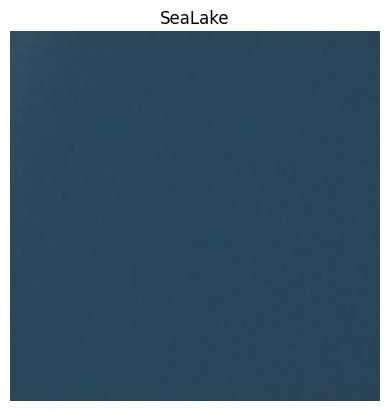

In [ ]:
import random
import matplotlib.pyplot as plt

# choose random class
sample_class = random.choice(classes)

# choose random image inside that class
sample_image = random.choice(os.listdir(os.path.join(data_path, sample_class)))

img_path = os.path.join(data_path, sample_class, sample_image)

img = plt.imread(img_path)

plt.imshow(img)
plt.title(sample_class)
plt.axis("off")
plt.show()


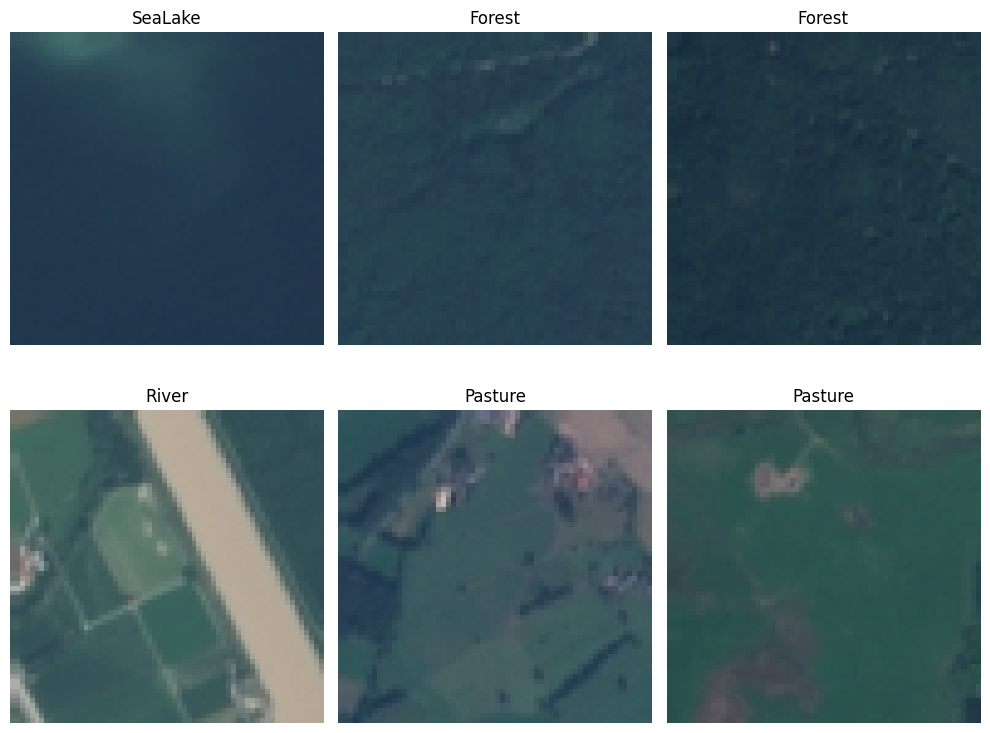

In [ ]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(10,8))

for i in range(6):
    sample_class = random.choice(classes)
    sample_image = random.choice(os.listdir(os.path.join(data_path, sample_class)))
    img_path = os.path.join(data_path, sample_class, sample_image)
    img = plt.imread(img_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(sample_class)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import os

# Create project folders
os.makedirs("/content/ISRO_Project/models", exist_ok=True)
os.makedirs("/content/ISRO_Project/results", exist_ok=True)
os.makedirs("/content/ISRO_Project/notebooks", exist_ok=True)

print("Project folders created successfully!")


Project folders created successfully!


In [ ]:
total_images = 0

for cls in classes:
    total_images += len(os.listdir(os.path.join(data_path, cls)))

print("Total images:", total_images)


Total images: 27000


In [ ]:
print("Image shape:", img.shape)


Image shape: (64, 64, 3)


In [ ]:
!ls


EuroSAT		     forest.jpg    ISRO_Project		 sample_data
EuroSATallBands      highway.jpg   land_use_model.keras
eurosat-dataset.zip  industry.jpg  model_b.keras


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,      # normalize pixel values (0–255 → 0–1)
    validation_split=0.2 # 20% for validation
)
train_generator = datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)
print(train_generator.class_indices)

Found 21600 images belonging to 10 classes.
{'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [ ]:
class_labels = list(train_generator.class_indices.keys())
print(class_labels)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
def get_predicted_class(prediction):
    return class_labels[np.argmax(prediction)]

In [ ]:
validation_generator = datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)


Found 5400 images belonging to 10 classes.
Image batch shape: (32, 64, 64, 3)
Label batch shape: (32, 10)


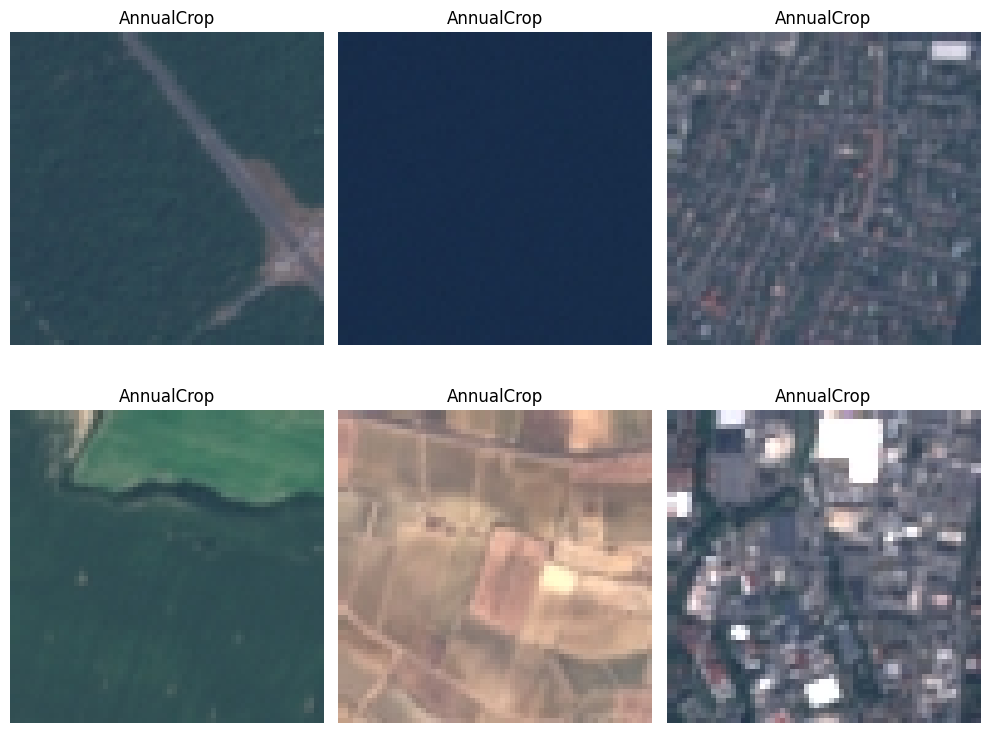

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = train_generator.class_indices
labels = {v: k for k, v in labels.items()}

plt.figure(figsize=(10,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    label_index = np.argmax(labels[i])
    plt.title(labels[label_index])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [ ]:
model = Sequential()


In [ ]:
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(64,64,3)
))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(MaxPooling2D(pool_size=(2,2)))


In [ ]:
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))


In [ ]:
model.add(Flatten())


In [ ]:
model.add(Dense(128, activation='relu'))


In [ ]:
model.add(Dense(10, activation='softmax'))


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 53824)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     6,889,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,910,282 (26.36 MB)

 Trainable params: 6,910,282 (26.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3
)


Epoch 1/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 24s 33ms/step - accuracy: 0.5463 - loss: 1.2392 - val_accuracy: 0.7022 - val_loss: 0.8230
Epoch 2/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7259 - loss: 0.7557 - val_accuracy: 0.7296 - val_loss: 0.7644
Epoch 3/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7897 - loss: 0.5886 - val_accuracy: 0.7909 - val_loss: 0.5938


In [ ]:
from tensorflow.keras.layers import Dropout

model_b = Sequential()


In [ ]:
model_b.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(64,64,3)
))

model_b.add(MaxPooling2D(pool_size=(2,2)))


In [ ]:
model_b.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

model_b.add(MaxPooling2D(pool_size=(2,2)))


In [ ]:
model_b.add(Flatten())

model_b.add(Dense(128, activation='relu'))

model_b.add(Dropout(0.5))


In [ ]:
model_b.add(Dense(10, activation='softmax'))


In [ ]:
model_b.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model_b.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_path = "land_use_model.keras"

if os.path.exists(model_path):
    print("Saved model found. Loading model...")
    model_b = load_model(model_path)

else:
    print("No saved model found. Training model...")

Saved model found. Loading model...


In [ ]:
history_b = model_b.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3
)


Epoch 1/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7285 - loss: 0.7685 - val_accuracy: 0.7806 - val_loss: 0.6262
Epoch 2/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7468 - loss: 0.7217 - val_accuracy: 0.7802 - val_loss: 0.6227
Epoch 3/3
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7634 - loss: 0.6713 - val_accuracy: 0.7776 - val_loss: 0.6171


In [ ]:
history_b = model_b.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5,
    initial_epoch=3
)
model_b.save("land_use_model.keras")
print("Model saved.")


Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7710 - loss: 0.6403 - val_accuracy: 0.8004 - val_loss: 0.5681
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7839 - loss: 0.6176 - val_accuracy: 0.7885 - val_loss: 0.5873
Model saved.


# Models Accuracy Graph

1.   List item
2.   List item



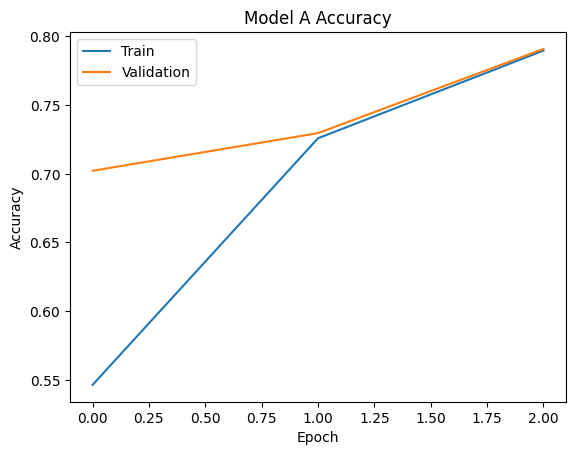

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model A Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


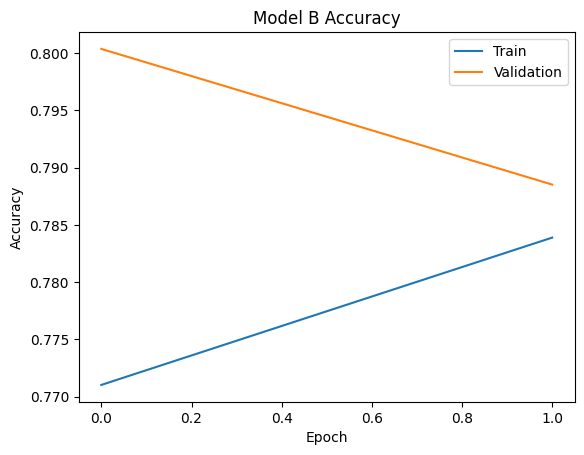

In [ ]:
plt.plot(history_b.history['accuracy'])
plt.plot(history_b.history['val_accuracy'])
plt.title('Model B Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


In [ ]:
augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
model_b.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,879,328 (18.61 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,252,886 (12.41 MB)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmented_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
train_generator_aug = augmented_datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator_aug = augmented_datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


In [ ]:
history_b_aug = model_b.fit(
    train_generator_aug,
    validation_data=validation_generator_aug,
    epochs=5
)

Epoch 1/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.7451 - loss: 0.7295 - val_accuracy: 0.7965 - val_loss: 0.5569
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.7536 - loss: 0.6950 - val_accuracy: 0.7622 - val_loss: 0.6672
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.7655 - loss: 0.6728 - val_accuracy: 0.7907 - val_loss: 0.5785
Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.7697 - loss: 0.6549 - val_accuracy: 0.7922 - val_loss: 0.5701
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 41s 60ms/step - accuracy: 0.7708 - loss: 0.6500 - val_accuracy: 0.7944 - val_loss: 0.5745


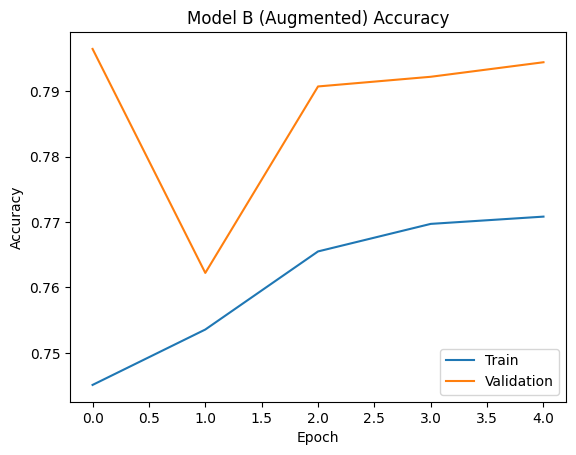

In [ ]:
plt.plot(history_b_aug.history['accuracy'])
plt.plot(history_b_aug.history['val_accuracy'])
plt.title('Model B (Augmented) Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
import numpy as np

# Get true labels
y_true = validation_generator_aug.classes

# Predict
y_pred_probs = model_b.predict(validation_generator_aug)
y_pred = np.argmax(y_pred_probs, axis=1)

169/169 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step


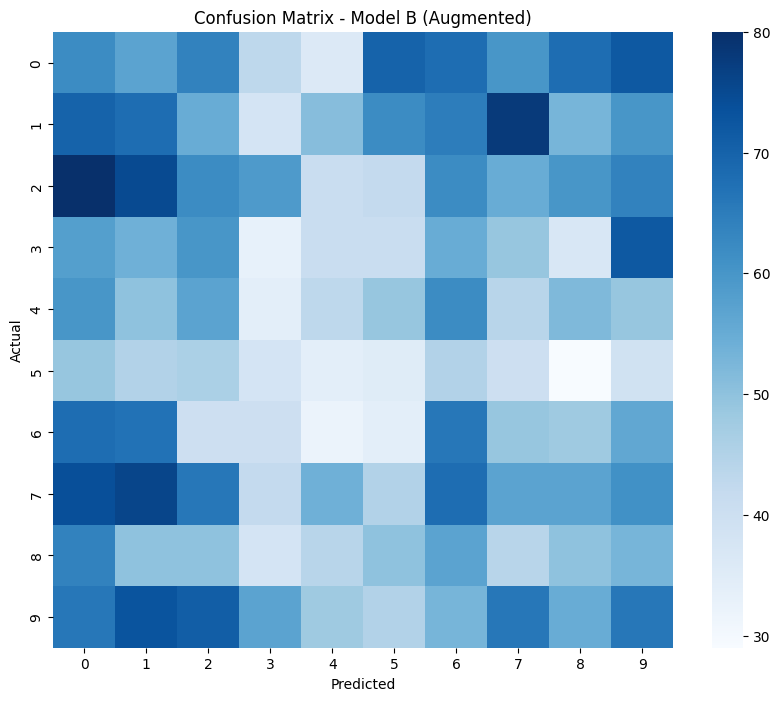

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - Model B (Augmented)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
class_indices = validation_generator_aug.class_indices
labels = list(class_indices.keys())

print(labels)

['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
import numpy as np

# Get indices of largest off-diagonal confusions
cm_copy = cm.copy()

# Remove diagonal
np.fill_diagonal(cm_copy, 0)

# Find top 5 largest confusion values
flat_indices = np.argsort(cm_copy, axis=None)[-5:]

for idx in flat_indices:
    i, j = np.unravel_index(idx, cm_copy.shape)
    print(f"Actual: {labels[i]} → Predicted: {labels[j]} | Count: {cm_copy[i][j]}")

Actual: Residential → Predicted: AnnualCrop | Count: 74
Actual: HerbaceousVegetation → Predicted: Forest | Count: 75
Actual: Residential → Predicted: Forest | Count: 76
Actual: Forest → Predicted: Residential | Count: 78
Actual: HerbaceousVegetation → Predicted: AnnualCrop | Count: 80


In [ ]:
for i in range(len(labels)):
    class_accuracy = cm[i][i] / np.sum(cm[i])
    print(f"{labels[i]} Accuracy: {class_accuracy:.2f}")

AnnualCrop Accuracy: 0.10
Forest Accuracy: 0.11
HerbaceousVegetation Accuracy: 0.10
Highway Accuracy: 0.07
Industrial Accuracy: 0.09
Pasture Accuracy: 0.09
PermanentCrop Accuracy: 0.13
Residential Accuracy: 0.10
River Accuracy: 0.10
SeaLake Accuracy: 0.11


# Testing the model

Actual Class: SeaLake
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted Class: SeaLake


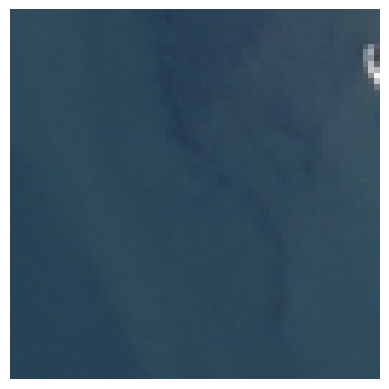

In [ ]:
import random
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Pick random class
random_class = random.choice(labels)

# Pick random image from that class
class_path = os.path.join("/content/EuroSAT", random_class)
random_image = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, random_image)

print("Actual Class:", random_class)

# Load image
img = image.load_img(img_path, target_size=(64, 64))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model_b.predict(img_array)
predicted_class = class_labels[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
for _ in range(10):
    random_class = random.choice(labels)
    class_path = os.path.join("/content/EuroSAT", random_class)
    random_image = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, random_image)

    img = image.load_img(img_path, target_size=(64, 64))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model_b.predict(img_array, verbose=0)
    predicted_class = class_labels[np.argmax(prediction)]
    print(f"Actual: {random_class} | Predicted: {predicted_class}")

Actual: PermanentCrop | Predicted: HerbaceousVegetation
Actual: Pasture | Predicted: Pasture
Actual: Pasture | Predicted: Pasture
Actual: PermanentCrop | Predicted: PermanentCrop
Actual: SeaLake | Predicted: SeaLake
Actual: HerbaceousVegetation | Predicted: HerbaceousVegetation
Actual: River | Predicted: River
Actual: Pasture | Predicted: Pasture
Actual: SeaLake | Predicted: AnnualCrop
Actual: SeaLake | Predicted: SeaLake


In [ ]:
model_b.save("model_b.keras")

In [ ]:
from tensorflow.keras.models import load_model

model_b = load_model("model_b.keras")
print("Model loaded successfully")

Model loaded successfully


## Sample Land Type Prediction
Run this section to test the model using sample images (such as
forest.jpg, industrial.jpg, and highway.jpg) present in notebook directory before running this.

Model prediction may vary depending on training accuracy.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted Class: Highway


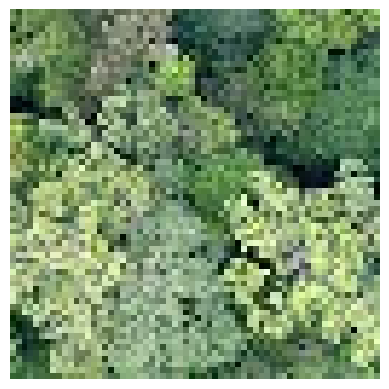

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load image
img = image.load_img("forest.jpg", target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model_b.predict(img_array)
predicted_class = class_labels[np.argmax(prediction)]
print("Predicted Class:", predicted_class)

# Show image
plt.imshow(img)
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Class: Industrial


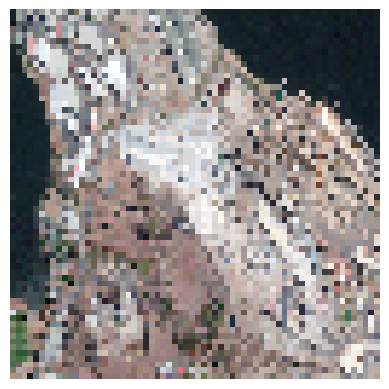

In [ ]:
img = image.load_img("industry.jpg", target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model_b.predict(img_array)
predicted_class = class_labels[np.argmax(prediction)]
print("Predicted Class:", predicted_class)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
import numpy as np

prediction = model_b.predict(img_array)

for i, prob in enumerate(prediction[0]):
    print(f"{labels[i]} : {prob:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
AnnualCrop : 0.0000
Forest : 0.0000
HerbaceousVegetation : 0.0005
Highway : 0.0006
Industrial : 0.8355
Pasture : 0.0000
PermanentCrop : 0.0000
Residential : 0.1634
River : 0.0000
SeaLake : 0.0000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Class: Industrial
AnnualCrop : 0.0000
Forest : 0.0000
HerbaceousVegetation : 0.0000
Highway : 0.0217
Industrial : 0.9782
Pasture : 0.0000
PermanentCrop : 0.0000
Residential : 0.0000
River : 0.0001
SeaLake : 0.0000


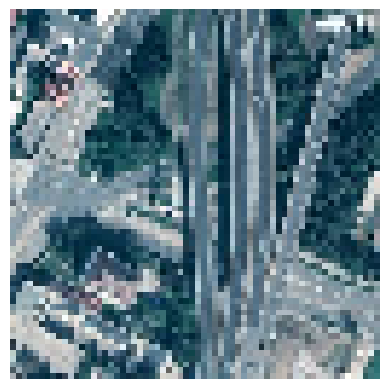

In [ ]:
img = image.load_img("highway.jpg", target_size=(64, 64))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model_b.predict(img_array)
predicted_class = class_labels[np.argmax(prediction)]
print("Predicted Class:", predicted_class)

for i, prob in enumerate(prediction[0]):
    print(f"{labels[i]} : {prob:.4f}")

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)

test_generator = datagen.flow_from_directory(
    "/content/EuroSAT",
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 27000 images belonging to 10 classes.


In [ ]:
test_loss, test_acc = model_b.evaluate(test_generator)
print("Test Accuracy:", test_acc)

844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8542 - loss: 0.4119
Test Accuracy: 0.854185163974762


In [ ]:
land_categories = {
    "Forest": "Natural",
    "River": "Natural",
    "SeaLake": "Natural",
    "HerbaceousVegetation": "Natural",
    "Pasture": "Natural",

    "AnnualCrop": "Agricultural",
    "PermanentCrop": "Agricultural",

    "Residential": "Built-Up",
    "Industrial": "Built-Up",
    "Highway": "Built-Up"
}

In [ ]:
def detect_change_advanced(img1_path, img2_path):

    class1, conf1, img1 = predict_image(img1_path)
    class2, conf2, img2 = predict_image(img2_path)

    category1 = land_categories[class1]
    category2 = land_categories[class2]

    confidence_delta = abs(conf2 - conf1)
    risk_score = (conf1 + conf2) / 2

    print("🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM")
    print("--------------------------------------------------")
    print(f"Image A: {class1} ({conf1*100:.2f}%) → Category: {category1}")
    print(f"Image B: {class2} ({conf2*100:.2f}%) → Category: {category2}")
    print("--------------------------------------------------")

    if class1 == class2:
        print("✅ No major land-use change detected.")
        impact = "Stable"
    else:
        print(f"⚠ Detected Transition: {category1} → {category2}")

        if category1 == "Natural" and category2 == "Built-Up":
            interpretation = "Urban / Infrastructure Expansion"
        elif category1 == "Natural" and category2 == "Agricultural":
            interpretation = "Agricultural Expansion"
        elif category1 == "Agricultural" and category2 == "Built-Up":
            interpretation = "Urban Encroachment on Agricultural Land"
        elif category1 == "Built-Up" and category2 == "Natural":
            interpretation = "Possible Land Restoration / Reforestation"
        else:
            interpretation = "Land-Use Structural Shift"

        print(f"🌍 Interpretation: {interpretation}")

        if risk_score > 0.85:
            impact = "High Impact"
        elif risk_score > 0.65:
            impact = "Moderate Impact"
        else:
            impact = "Low Confidence Shift"

        print(f"📊 Risk Score: {risk_score:.2f}")
        print(f"🚨 Impact Level: {impact}")

    print("--------------------------------------------------")

    # Display images side by side
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(img1)
    plt.title("Before")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(img2)
    plt.title("After")
    plt.axis("off")

    plt.show()

# DEMO SECTION
Upload two - BEFORE and AFTER satellite images

(sample before and after images are given in directory)

Upload BEFORE and AFTER satellite images


Saving after.jpg to after (2).jpg
Saving before.jpg to before (2).jpg
🛰 SATELLITE LAND-USE CHANGE DETECTION SYSTEM
--------------------------------------------------
Image A Prediction: Industrial (97.67%)
Image B Prediction: Pasture (88.87%)
--------------------------------------------------
⚠ Land-use change detected!
🔎 Change observed between land-use categories.
--------------------------------------------------


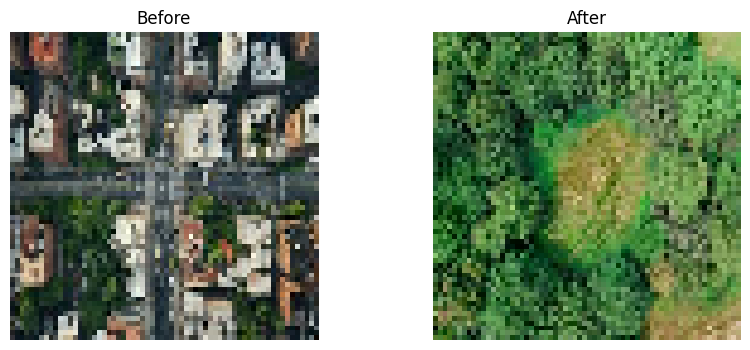

In [ ]:
from google.colab import files

print("Upload BEFORE and AFTER satellite images")

uploaded = files.upload()

image_names = list(uploaded.keys())

if len(image_names) < 2:
    print("Please upload TWO images (Before and After).")
else:
    before_image = image_names[0]
    after_image = image_names[1]

    detect_change(before_image, after_image)

🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM
--------------------------------------------------
Image A: Industrial (97.67%) → Category: Built-Up
Image B: Pasture (88.87%) → Category: Natural
--------------------------------------------------
⚠ Detected Transition: Built-Up → Natural
🌍 Interpretation: Possible Land Restoration / Reforestation
📊 Risk Score: 0.93
🚨 Impact Level: High Impact
--------------------------------------------------


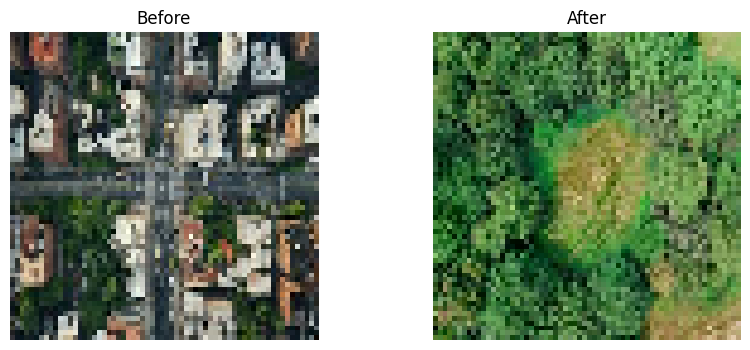

In [ ]:
detect_change_advanced(before_image, after_image)

🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM
--------------------------------------------------
Image A: Pasture (88.87%) → Category: Natural
Image B: Industrial (97.67%) → Category: Built-Up
--------------------------------------------------
⚠ Detected Transition: Natural → Built-Up
🌍 Interpretation: Urban / Infrastructure Expansion
📊 Risk Score: 0.93
🚨 Impact Level: High Impact
--------------------------------------------------


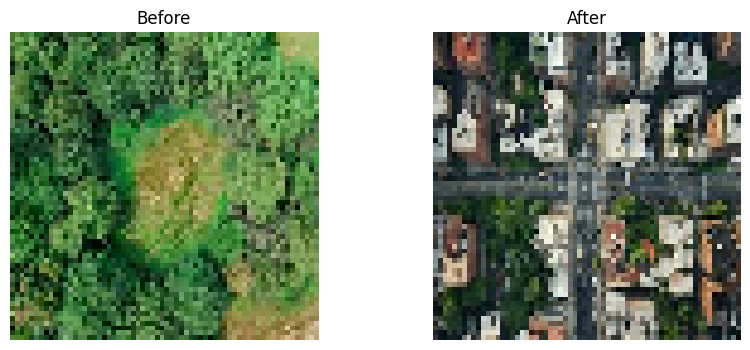

In [ ]:
detect_change_advanced(after_image, before_image)

In [ ]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(64, 64))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model_b.predict(img_array, verbose=0)
    predicted_class = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction)

    return predicted_class, confidence, prediction[0], img

In [ ]:
def detect_change_advanced(img1_path, img2_path):

    class1, conf1, probs1, img1 = predict_image(img1_path)
    class2, conf2, probs2, img2 = predict_image(img2_path)

    category1 = land_categories[class1]
    category2 = land_categories[class2]

    risk_score = (conf1 + conf2) / 2

    print("🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM")
    print("--------------------------------------------------")
    print(f"Image A: {class1} ({conf1*100:.2f}%) → Category: {category1}")
    print(f"Image B: {class2} ({conf2*100:.2f}%) → Category: {category2}")
    print("--------------------------------------------------")

    if class1 == class2:
        print("✅ No major land-use change detected.")
        impact = "Stable"
    else:
        print(f"⚠ Detected Transition: {category1} → {category2}")

        if category1 == "Natural" and category2 == "Built-Up":
            interpretation = "Urban / Infrastructure Expansion"
        elif category1 == "Natural" and category2 == "Agricultural":
            interpretation = "Agricultural Expansion"
        elif category1 == "Agricultural" and category2 == "Built-Up":
            interpretation = "Urban Encroachment on Agricultural Land"
        elif category1 == "Built-Up" and category2 == "Natural":
            interpretation = "Possible Land Restoration / Reforestation"
        else:
            interpretation = "Land-Use Structural Shift"

        print(f"🌍 Interpretation: {interpretation}")

        if risk_score > 0.85:
            impact = "High Impact"
        elif risk_score > 0.65:
            impact = "Moderate Impact"
        else:
            impact = "Low Confidence Shift"

        print(f"📊 Risk Score: {risk_score:.2f}")
        print(f"🚨 Impact Level: {impact}")

    print("--------------------------------------------------")

    # Show images
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img1)
    plt.title("Before")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(img2)
    plt.title("After")
    plt.axis("off")

    # Bar chart comparison
    plt.subplot(1,3,3)
    x = np.arange(len(labels))
    width = 0.35
    plt.bar(x - width/2, probs1, width, label="Before")
    plt.bar(x + width/2, probs2, width, label="After")
    plt.xticks(x, labels, rotation=90)
    plt.title("Confidence Comparison")
    plt.legend()

    plt.tight_layout()
    plt.show()

🛰 AI-DRIVEN LAND-USE TRANSITION ANALYSIS SYSTEM
--------------------------------------------------
Image A: Industrial (97.67%) → Category: Built-Up
Image B: Pasture (88.87%) → Category: Natural
--------------------------------------------------
⚠ Detected Transition: Built-Up → Natural
🌍 Interpretation: Possible Land Restoration / Reforestation
📊 Risk Score: 0.93
🚨 Impact Level: High Impact
--------------------------------------------------


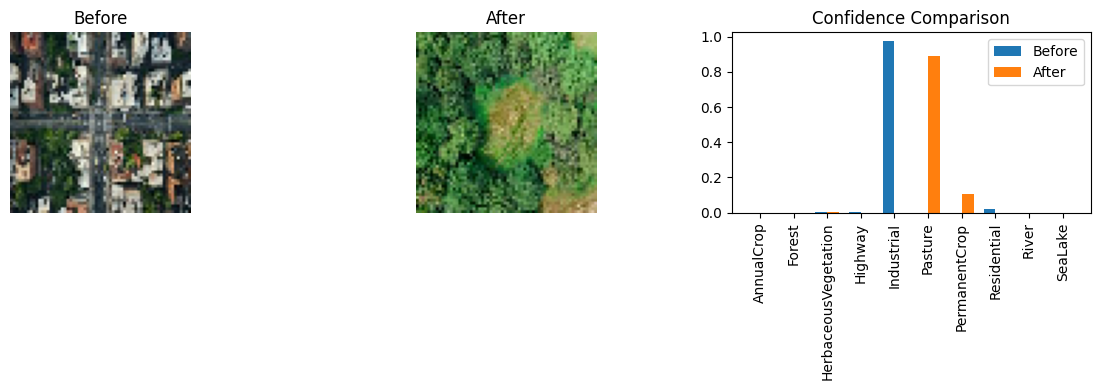

In [ ]:
detect_change_advanced(before_image, after_image)